In [20]:
# E3.ipynb

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [21]:
# To ensure reproducibility
np.random.seed(42)

# Read data from Excel file
file_path = 'E3.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')

In [22]:
# Separate features and target variable in train data
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

# Separate features and target variable in test data
X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

In [23]:
# # Adding outliers (UNCOMMENT ONLY WHEN REQUIRED! SEE THE PROBLEM STATEMENTs ...)
# X_train = np.array(list(X_train['x1']) + [X_train['x1'].mean() + x for x in np.random.randn(5)]).reshape(-1,1)
# y_train = np.array(list(y_train) + [y_train.max() + 4 + x for x in np.random.randn(5)])

In [24]:
# Use PolynomialFeatures to create features
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [25]:
# standardization of the data
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

In [26]:
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_train_poly, columns=feature_names)
augmented_data['y'] = train_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_train_data.csv', index=False)
####################################
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_test_poly, columns=feature_names)
augmented_data['y'] = test_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_test_data.csv', index=False)
####################################

In [27]:
# Algorithms
algorithms = {
    'Linear Regression': LinearRegression(),
    'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
    'RandomForest': RandomForestRegressor(),
    'XGBoost': GradientBoostingRegressor(),
    'knn': KNeighborsRegressor(),
    'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
}

# Metric tables
metric_table_train = pd.DataFrame()
metric_table_test = pd.DataFrame()

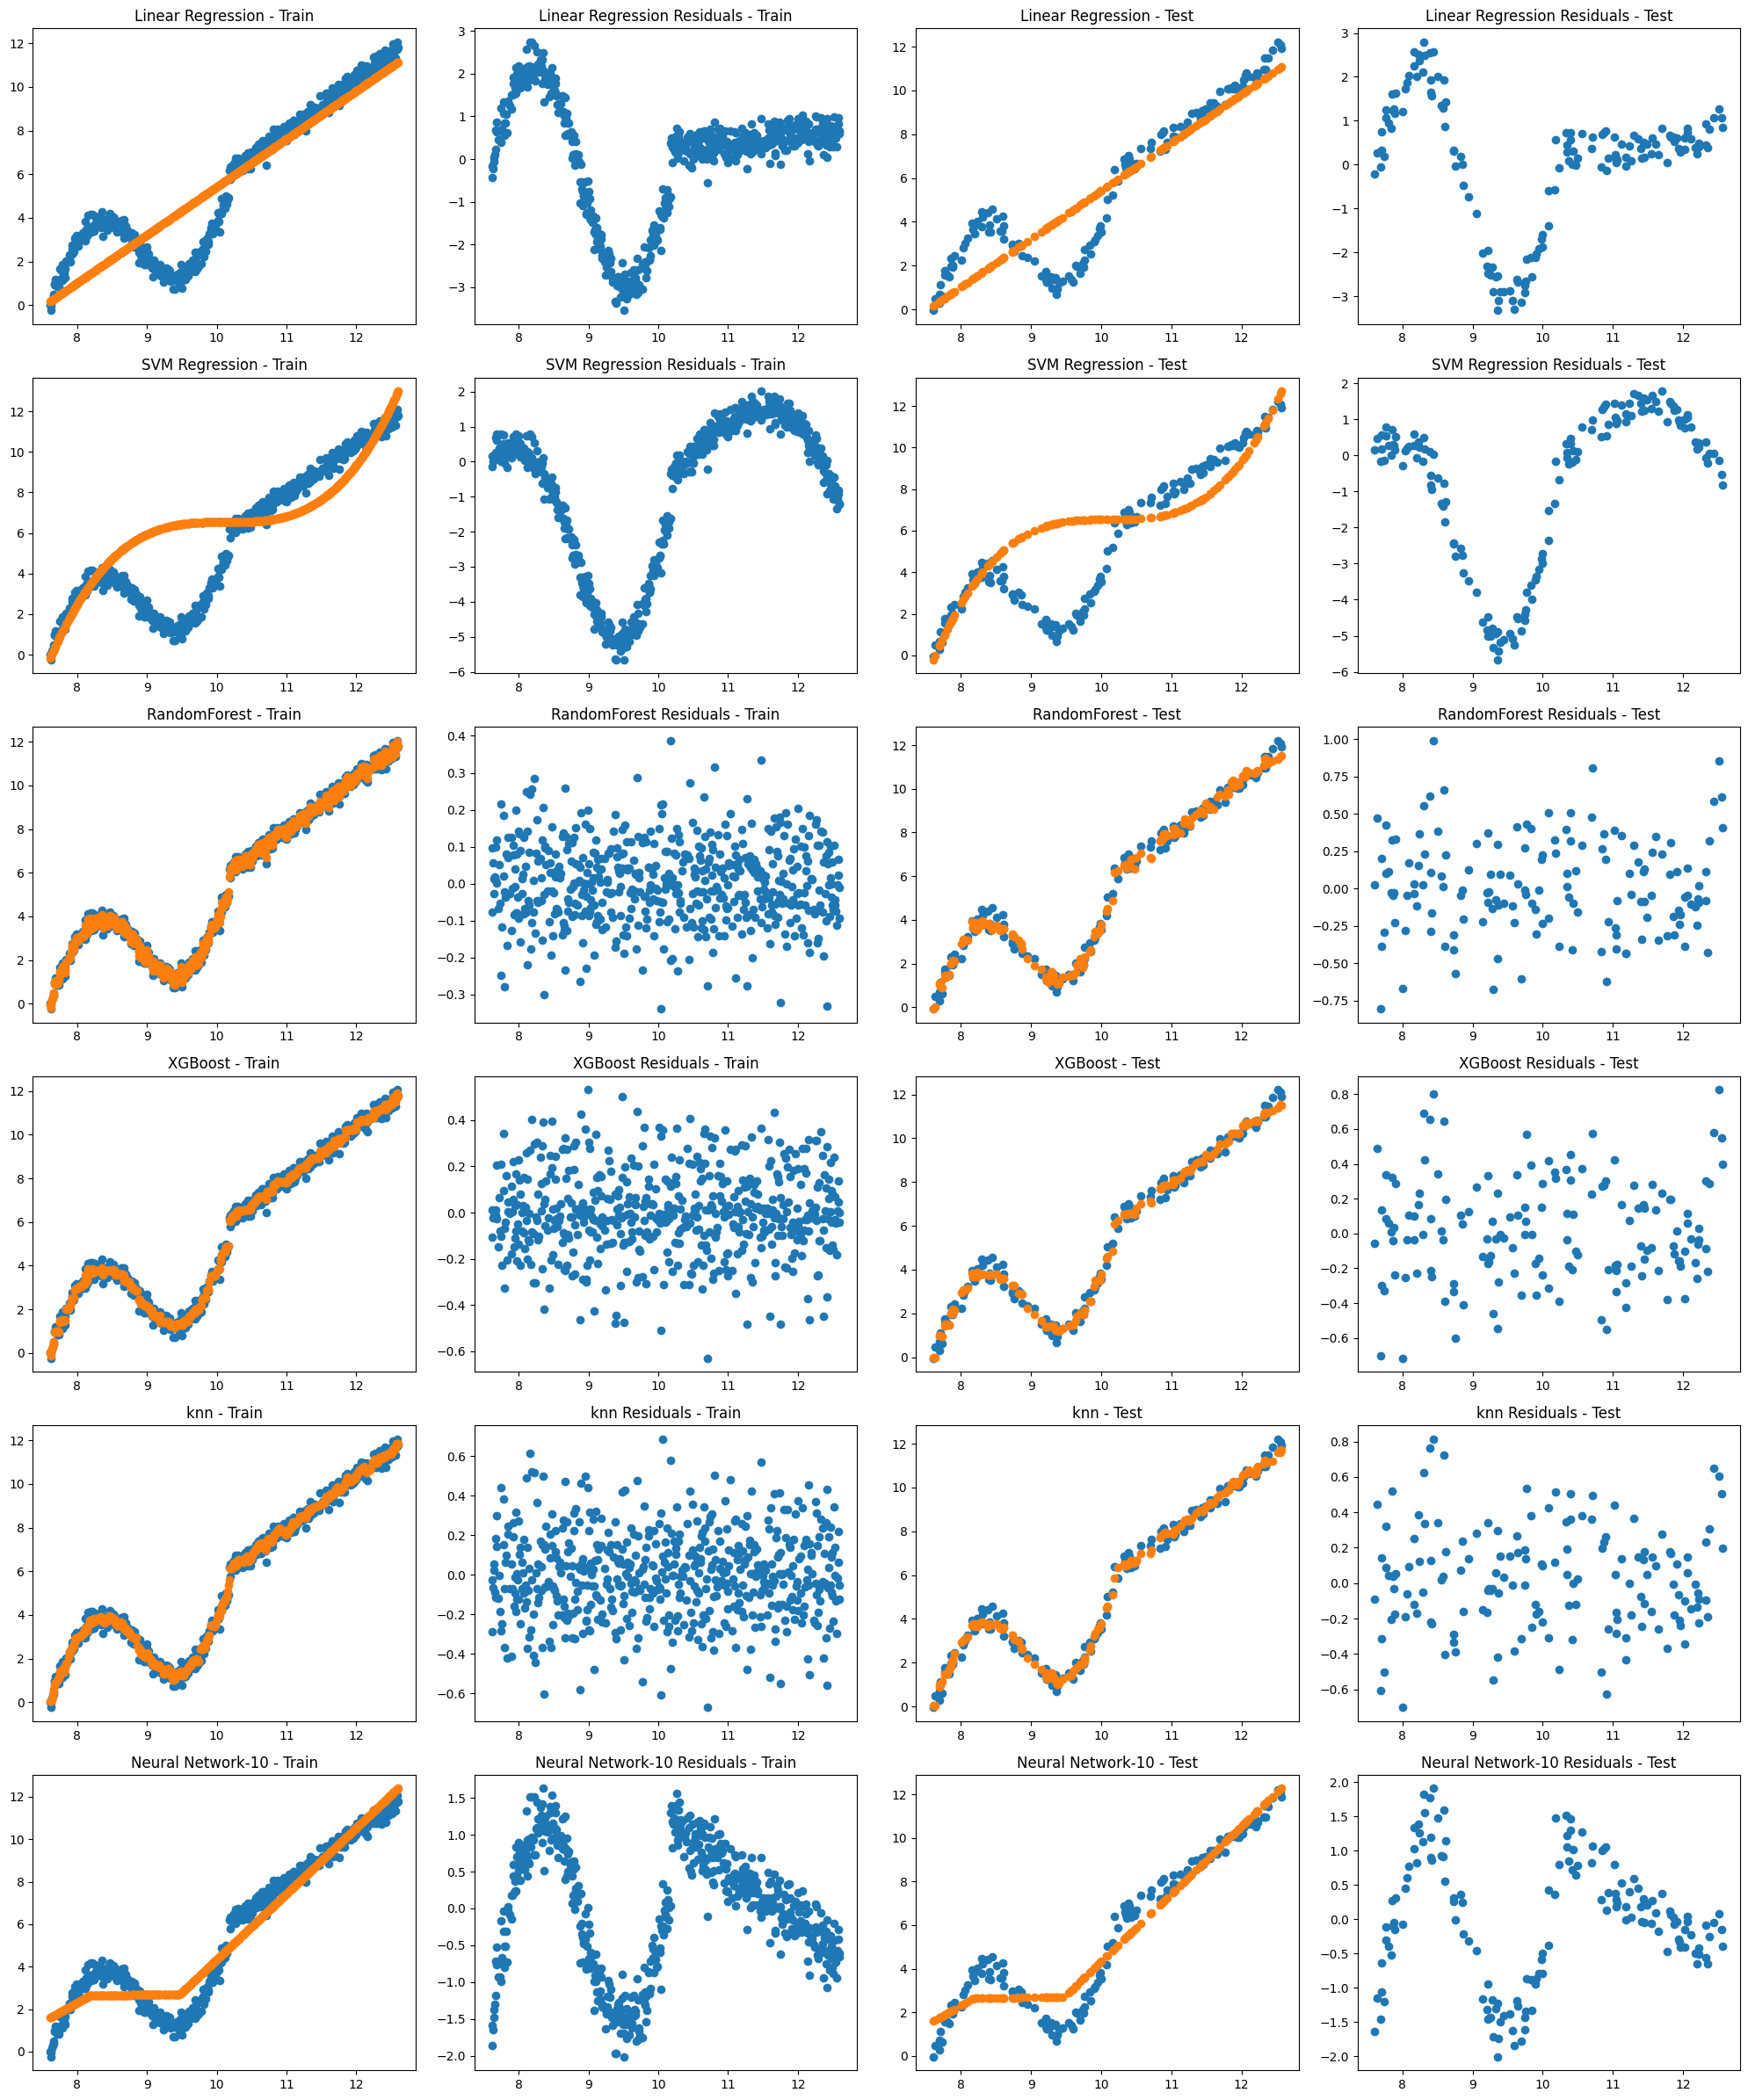

In [28]:
# Create a grid of subplots
fig, axs = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row = -1

# Run the algorithms ... create metrics and plots
for algorithm_name, algorithm in algorithms.items():

    # Train model
    algorithm.fit(X_train_poly, y_train)

    # Train predictions
    y_train_pred = algorithm.predict(X_train_poly)

    # Test predictions
    y_test_pred = algorithm.predict(X_test_poly)

    # Train metrics
    r2_train = algorithm.score(X_train_poly, y_train)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)

    # Test metrics
    r2_test = algorithm.score(X_test_poly, y_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Additional metrics using statsmodels for all algorithms
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
    jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

    durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
    jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)

    # Update metric tables
    metric_table_train.at[algorithm_name, 'R-squared'] = r2_train
    metric_table_train.at[algorithm_name, 'RMSE'] = rmse_train
    metric_table_train.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_train
    metric_table_train.at[algorithm_name, 'Jarque-Bera'] = jb_stat_train
    metric_table_train.at[algorithm_name, 'JB P-value'] = jb_p_value_train

    metric_table_test.at[algorithm_name, 'R-squared'] = r2_test
    metric_table_test.at[algorithm_name, 'RMSE'] = rmse_test
    metric_table_test.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_test
    metric_table_test.at[algorithm_name, 'Jarque-Bera'] = jb_stat_test
    metric_table_test.at[algorithm_name, 'JB P-value'] = jb_p_value_test

    # Create the plots
    fig_row = fig_row+1

    axs[fig_row, 0].scatter(X_train, y_train)
    axs[fig_row, 0].scatter(X_train, y_train_pred)
    axs[fig_row, 0].set_title(algorithm_name + " - Train")

    axs[fig_row, 1].scatter(X_train, residuals_train)
    axs[fig_row, 1].set_title(algorithm_name + " Residuals - Train")

    axs[fig_row, 2].scatter(X_test, y_test)
    axs[fig_row, 2].scatter(X_test, y_test_pred)
    axs[fig_row, 2].set_title(algorithm_name + " - Test")

    axs[fig_row, 3].scatter(X_test, residuals_test)
    axs[fig_row, 3].set_title(algorithm_name + " Residuals - Test")
############################

plt.tight_layout()
plt.show()

In [29]:
# Display the metrics' Tables
print("Metrics - Train Data:\n")
print(metric_table_train.to_string())
print("-------------------------------------------------")

print("Metrics - Test Data:\n")
print(metric_table_test.to_string())

Metrics - Train Data:

                   R-squared      RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression   0.833674  1.408923       0.059761    51.466506  6.670987e-12
SVM Regression      0.545415  2.329245       0.021942    68.878362  1.104724e-15
RandomForest        0.999000  0.109241       2.931659     3.769479  1.518686e-01
XGBoost             0.997146  0.184549       2.372918     1.046859  5.924852e-01
knn                 0.995929  0.220416       2.510498     0.705376  7.027965e-01
Neural Network-10   0.939374  0.850625       0.162938    22.918092  1.055357e-05
-------------------------------------------------
Metrics - Test Data:

                   R-squared      RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression   0.818068  1.501800       0.079118    12.500550    0.001930
SVM Regression      0.562991  2.327567       0.034813    23.409392    0.000008
RandomForest        0.991747  0.319861       1.834557     0.904898    0.636068
XGBoost             0.

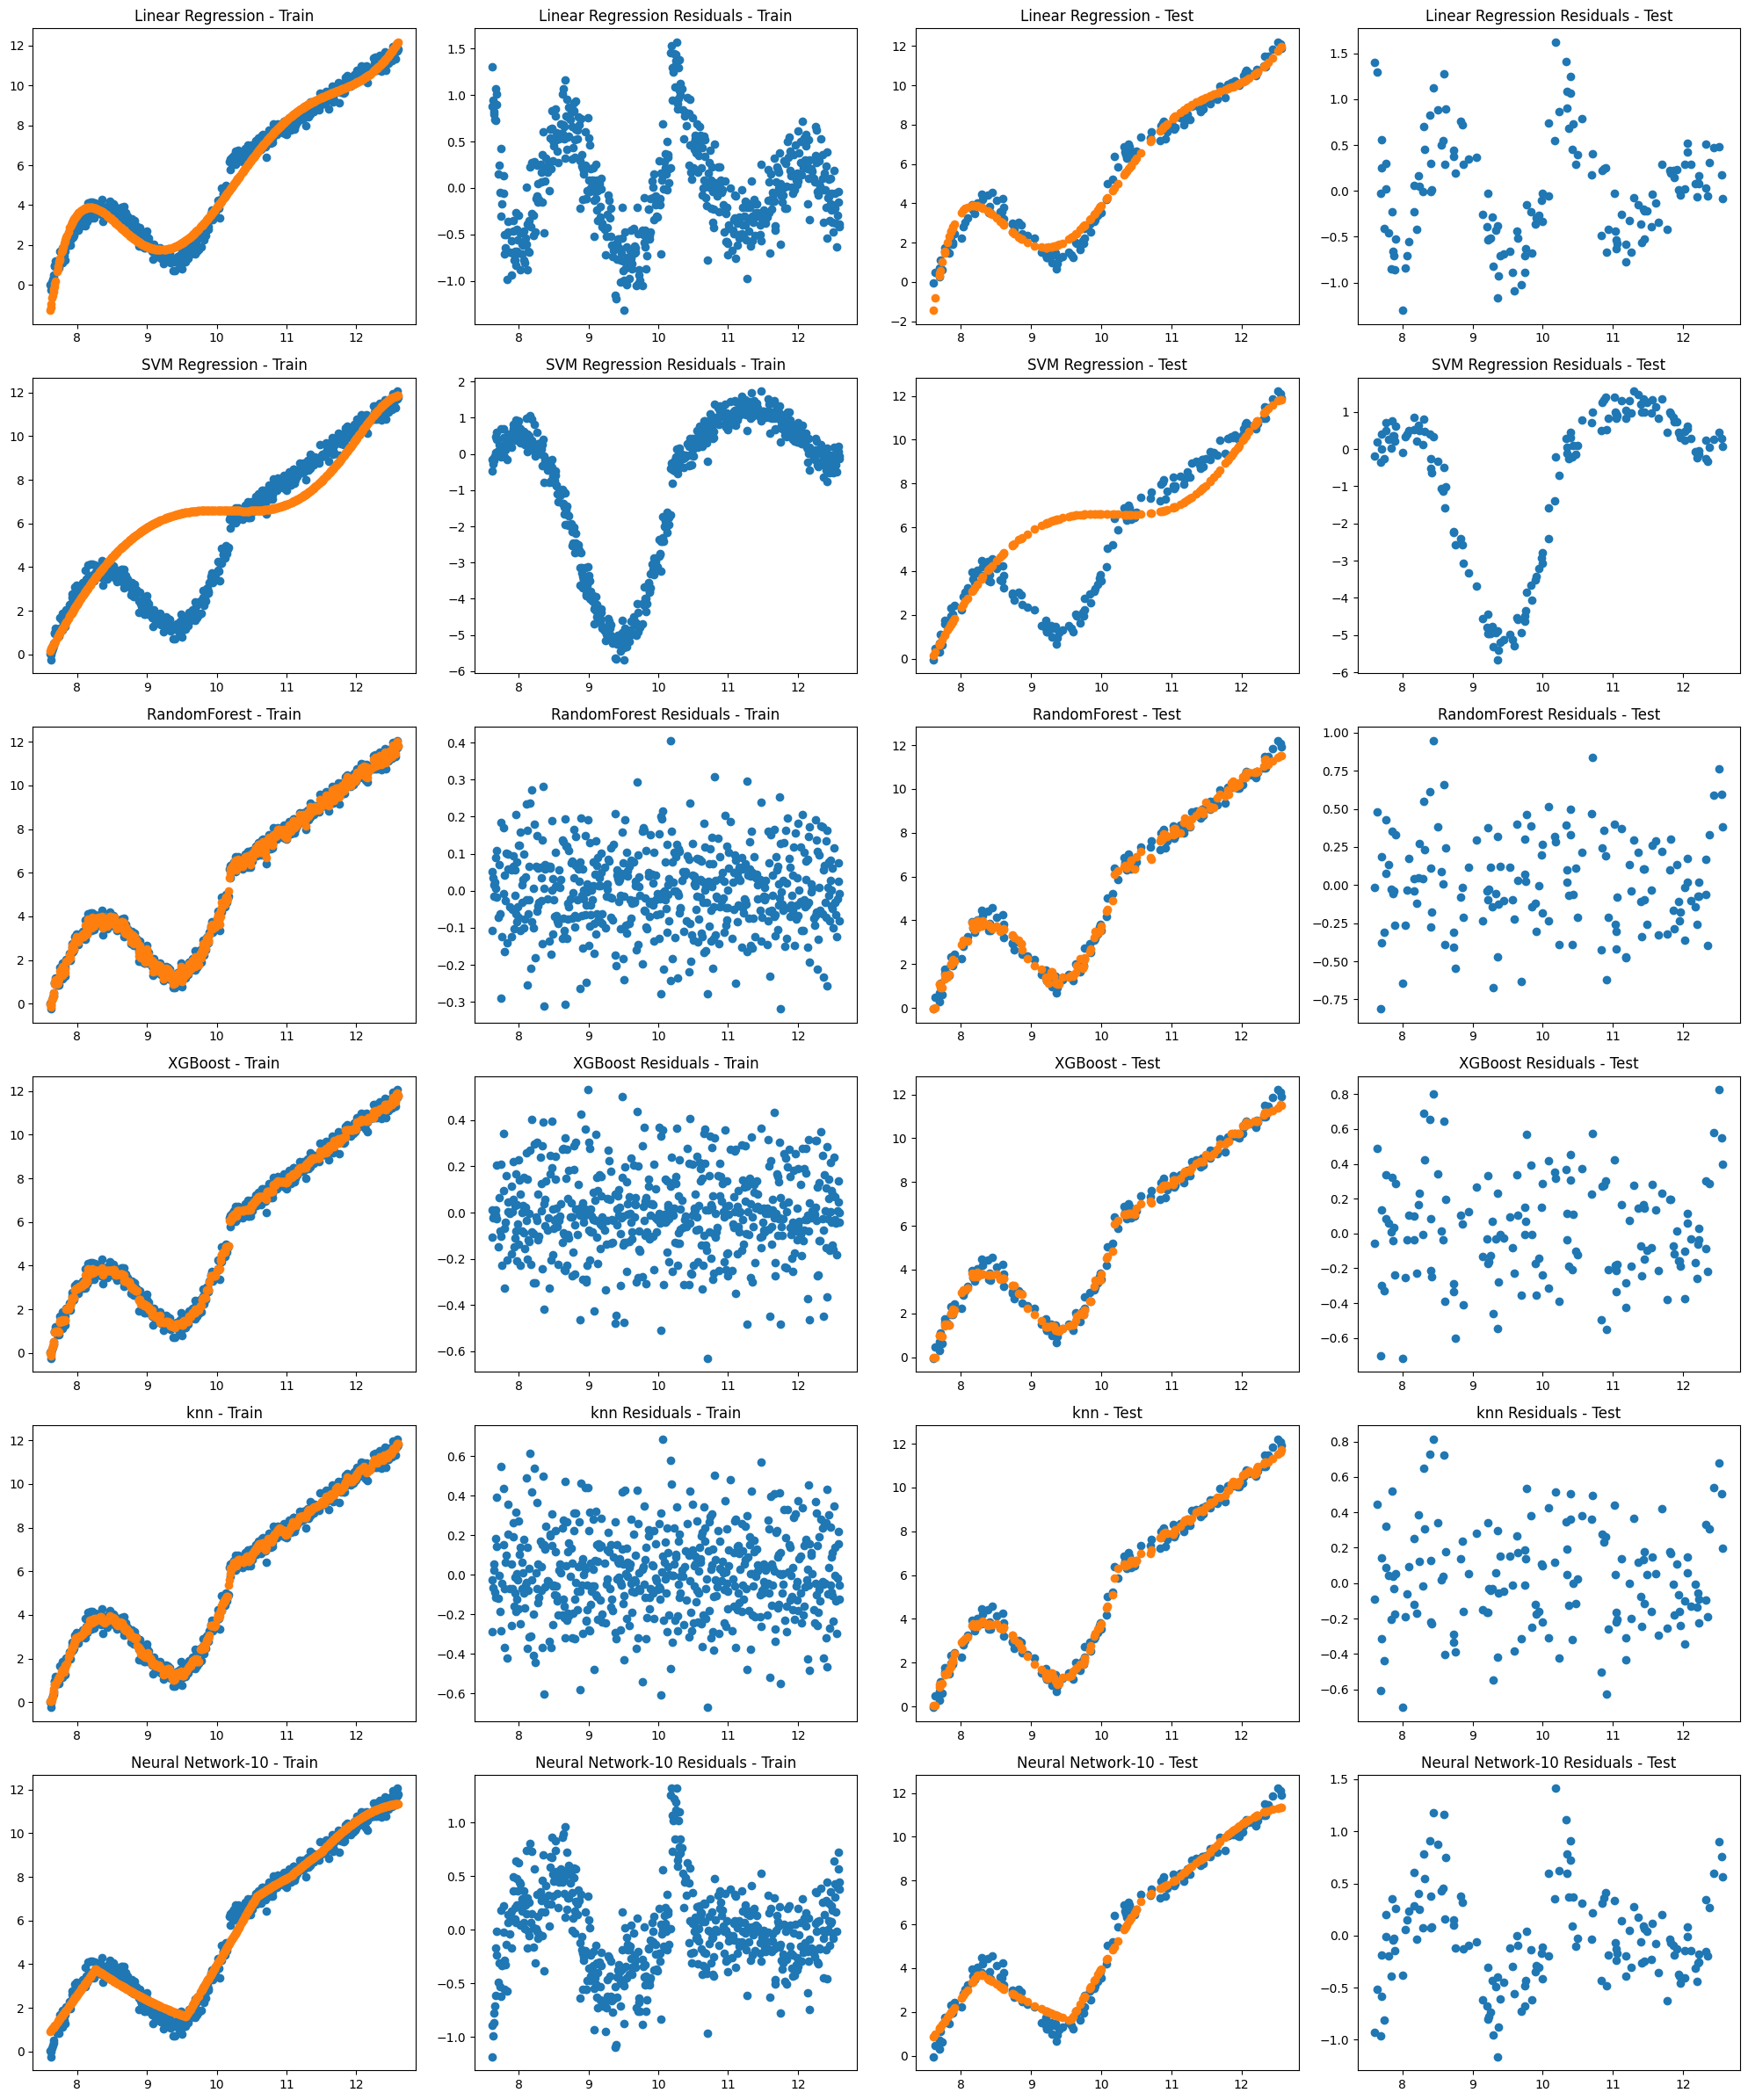

In [30]:
#for degree 6


poly = PolynomialFeatures(degree=6)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# standardization of the data
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_train_poly, columns=feature_names)
augmented_data['y'] = train_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_train_data.csv', index=False)
####################################
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_test_poly, columns=feature_names)
augmented_data['y'] = test_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_test_data.csv', index=False)
####################################


# Algorithms
algorithms = {
    'Linear Regression': LinearRegression(),
    'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
    'RandomForest': RandomForestRegressor(),
    'XGBoost': GradientBoostingRegressor(),
    'knn': KNeighborsRegressor(),
    'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
}

# Metric tables
metric_table_train = pd.DataFrame()
metric_table_test = pd.DataFrame()


# Create a grid of subplots
fig, axs = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row = -1

# Run the algorithms ... create metrics and plots
for algorithm_name, algorithm in algorithms.items():

    # Train model
    algorithm.fit(X_train_poly, y_train)

    # Train predictions
    y_train_pred = algorithm.predict(X_train_poly)

    # Test predictions
    y_test_pred = algorithm.predict(X_test_poly)

    # Train metrics
    r2_train = algorithm.score(X_train_poly, y_train)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)

    # Test metrics
    r2_test = algorithm.score(X_test_poly, y_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Additional metrics using statsmodels for all algorithms
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
    jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

    durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
    jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)

    # Update metric tables
    metric_table_train.at[algorithm_name, 'R-squared'] = r2_train
    metric_table_train.at[algorithm_name, 'RMSE'] = rmse_train
    metric_table_train.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_train
    metric_table_train.at[algorithm_name, 'Jarque-Bera'] = jb_stat_train
    metric_table_train.at[algorithm_name, 'JB P-value'] = jb_p_value_train

    metric_table_test.at[algorithm_name, 'R-squared'] = r2_test
    metric_table_test.at[algorithm_name, 'RMSE'] = rmse_test
    metric_table_test.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_test
    metric_table_test.at[algorithm_name, 'Jarque-Bera'] = jb_stat_test
    metric_table_test.at[algorithm_name, 'JB P-value'] = jb_p_value_test

    # Create the plots
    fig_row = fig_row+1

    axs[fig_row, 0].scatter(X_train, y_train)
    axs[fig_row, 0].scatter(X_train, y_train_pred)
    axs[fig_row, 0].set_title(algorithm_name + " - Train")

    axs[fig_row, 1].scatter(X_train, residuals_train)
    axs[fig_row, 1].set_title(algorithm_name + " Residuals - Train")

    axs[fig_row, 2].scatter(X_test, y_test)
    axs[fig_row, 2].scatter(X_test, y_test_pred)
    axs[fig_row, 2].set_title(algorithm_name + " - Test")

    axs[fig_row, 3].scatter(X_test, residuals_test)
    axs[fig_row, 3].set_title(algorithm_name + " Residuals - Test")
############################

plt.tight_layout()
plt.show()

In [31]:
# Display the metrics' Tables
print("Metrics - Train Data:\n")
print(metric_table_train.to_string())
print("-------------------------------------------------")

print("Metrics - Test Data:\n")
print(metric_table_test.to_string())

Metrics - Train Data:

                   R-squared      RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression   0.976261  0.532278       0.417086    11.050745  3.984384e-03
SVM Regression      0.566637  2.274224       0.023043    83.011284  9.426029e-19
RandomForest        0.998993  0.109618       2.914663     2.469639  2.908873e-01
XGBoost             0.997146  0.184549       2.372918     1.046859  5.924852e-01
knn                 0.995895  0.221345       2.505231     0.733304  6.930509e-01
Neural Network-10   0.985794  0.411762       0.695208    13.489563  1.177006e-03
-------------------------------------------------
Metrics - Test Data:

                   R-squared      RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression   0.972925  0.579348       0.528190     3.916151    0.141130
SVM Regression      0.578190  2.286733       0.035979    27.177218    0.000001
RandomForest        0.991851  0.317832       1.877737     0.410184    0.814573
XGBoost             0.

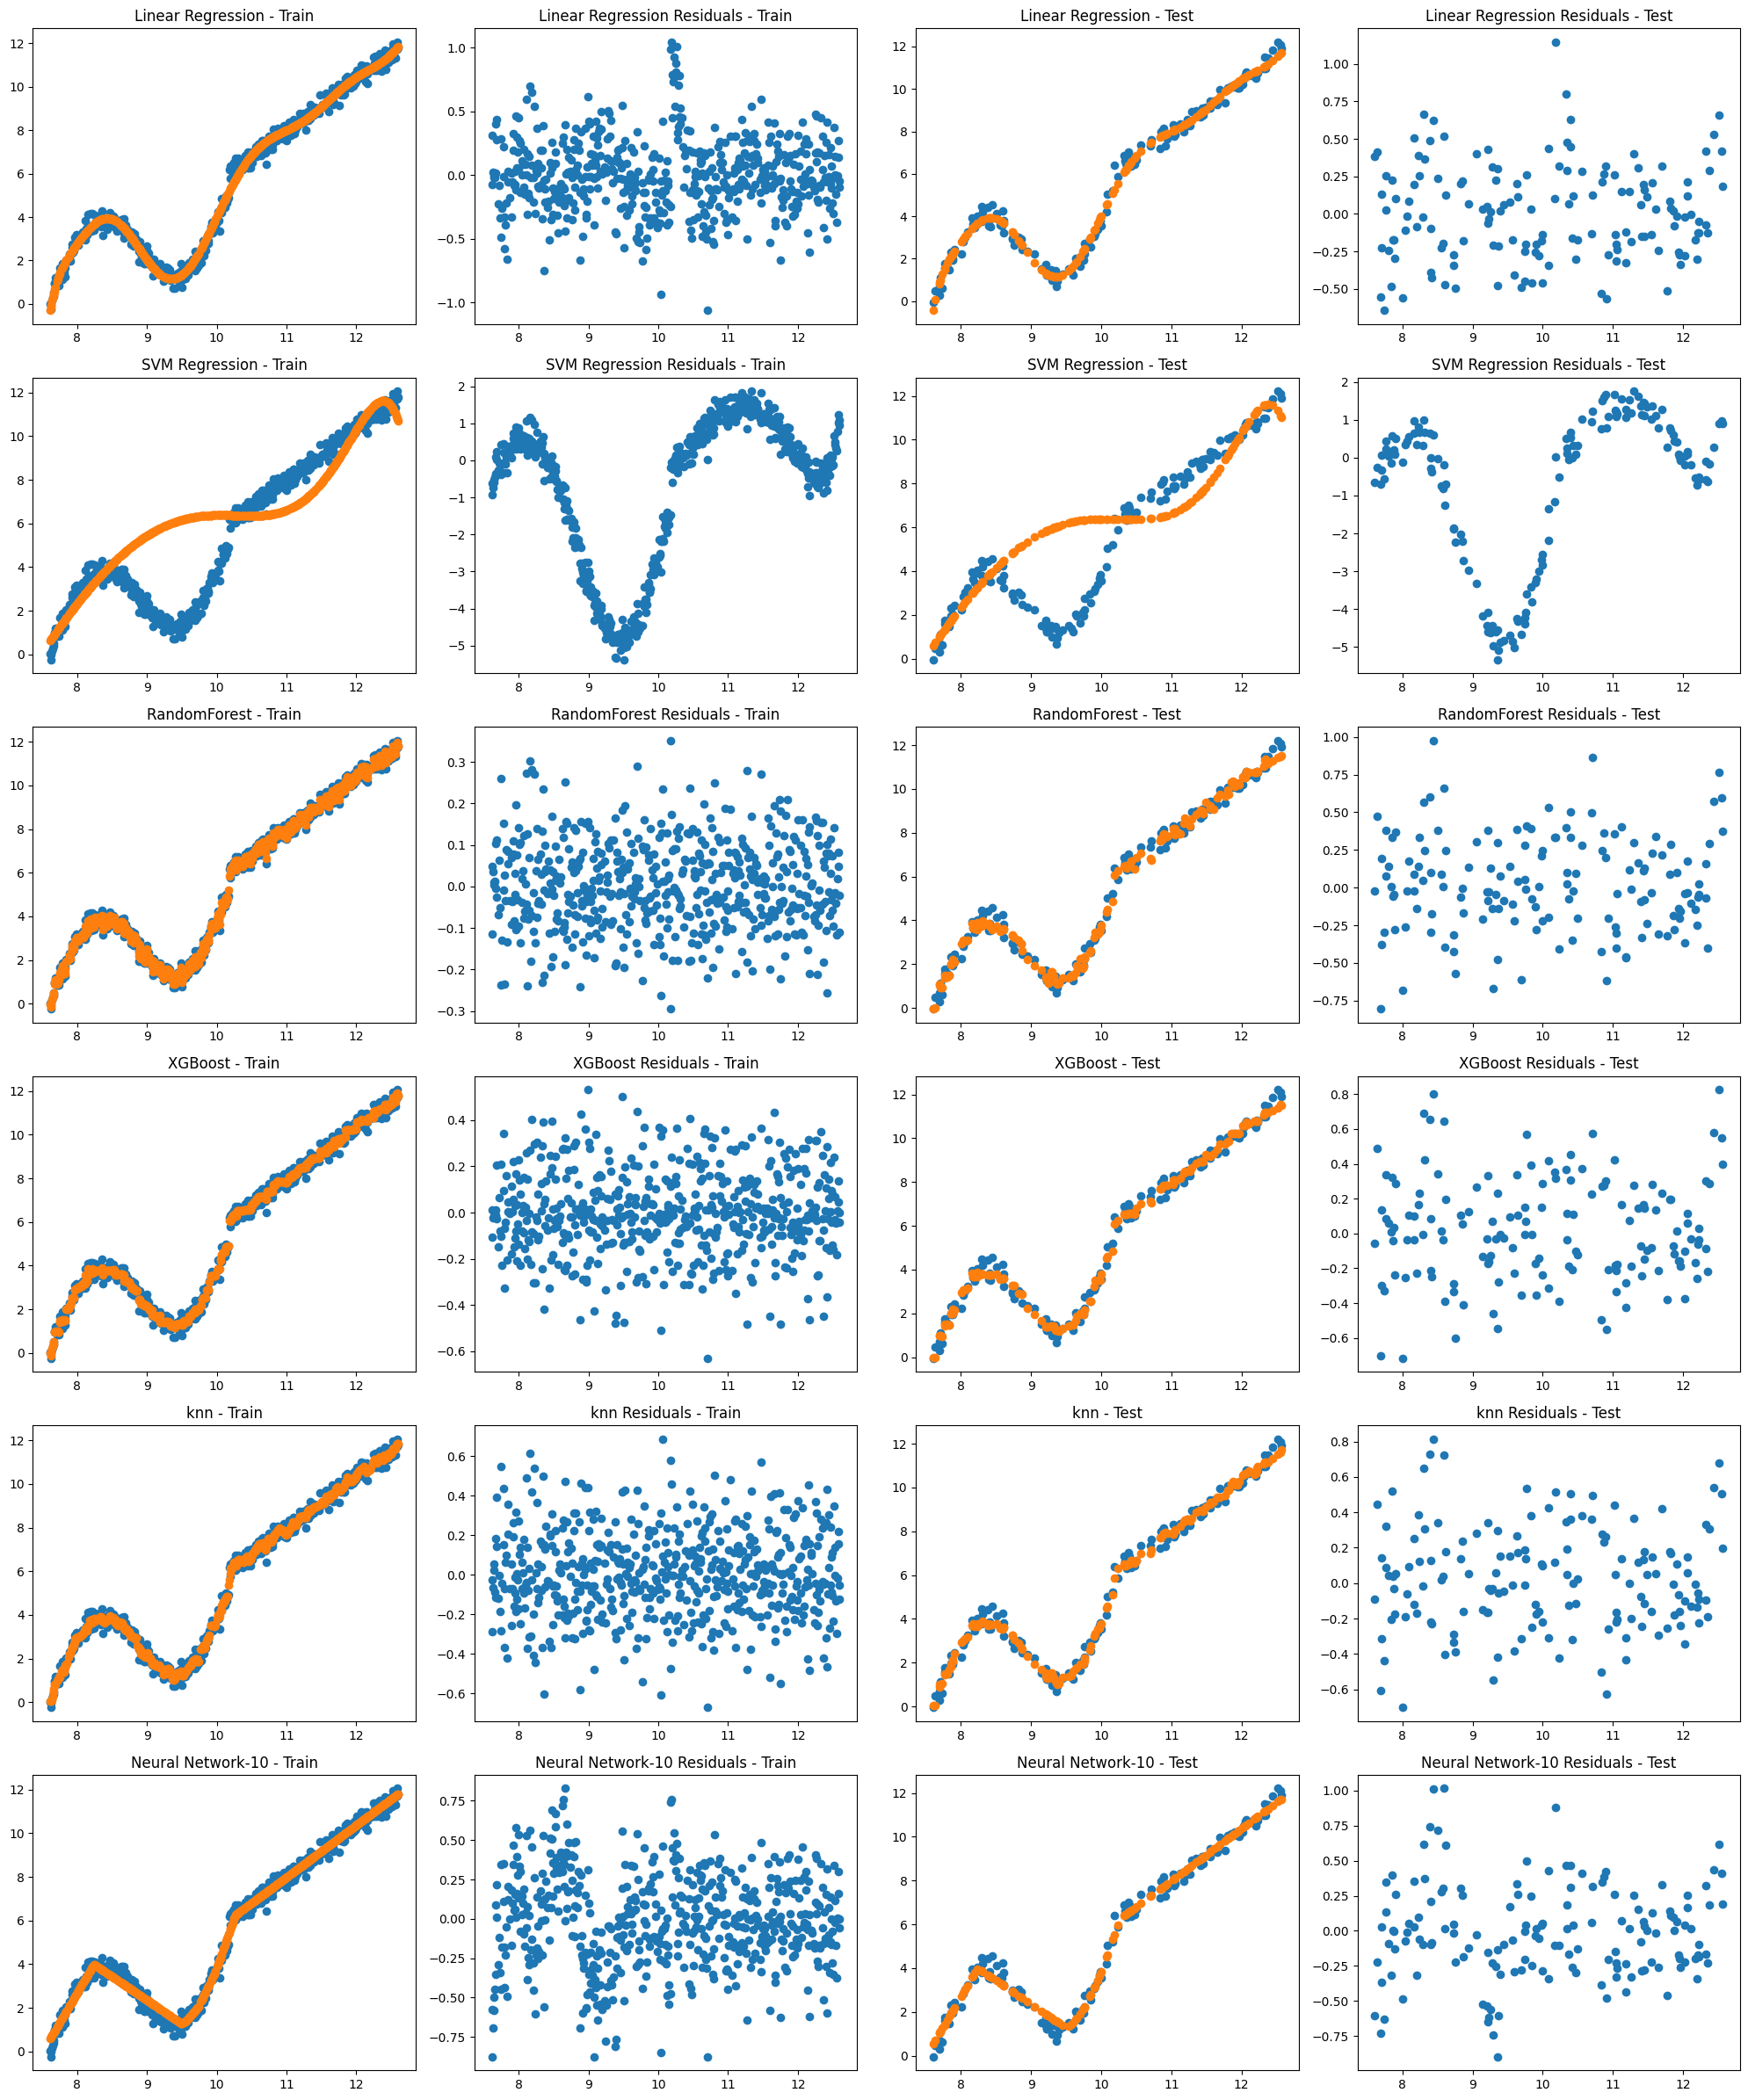

In [32]:
#for degree 10


poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# standardization of the data
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_train_poly, columns=feature_names)
augmented_data['y'] = train_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_train_data.csv', index=False)
####################################
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_test_poly, columns=feature_names)
augmented_data['y'] = test_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_test_data.csv', index=False)
####################################


# Algorithms
algorithms = {
    'Linear Regression': LinearRegression(),
    'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
    'RandomForest': RandomForestRegressor(),
    'XGBoost': GradientBoostingRegressor(),
    'knn': KNeighborsRegressor(),
    'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
}

# Metric tables
metric_table_train = pd.DataFrame()
metric_table_test = pd.DataFrame()


# Create a grid of subplots
fig, axs = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row = -1

# Run the algorithms ... create metrics and plots
for algorithm_name, algorithm in algorithms.items():

    # Train model
    algorithm.fit(X_train_poly, y_train)

    # Train predictions
    y_train_pred = algorithm.predict(X_train_poly)

    # Test predictions
    y_test_pred = algorithm.predict(X_test_poly)

    # Train metrics
    r2_train = algorithm.score(X_train_poly, y_train)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)

    # Test metrics
    r2_test = algorithm.score(X_test_poly, y_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Additional metrics using statsmodels for all algorithms
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
    jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

    durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
    jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)

    # Update metric tables
    metric_table_train.at[algorithm_name, 'R-squared'] = r2_train
    metric_table_train.at[algorithm_name, 'RMSE'] = rmse_train
    metric_table_train.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_train
    metric_table_train.at[algorithm_name, 'Jarque-Bera'] = jb_stat_train
    metric_table_train.at[algorithm_name, 'JB P-value'] = jb_p_value_train

    metric_table_test.at[algorithm_name, 'R-squared'] = r2_test
    metric_table_test.at[algorithm_name, 'RMSE'] = rmse_test
    metric_table_test.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_test
    metric_table_test.at[algorithm_name, 'Jarque-Bera'] = jb_stat_test
    metric_table_test.at[algorithm_name, 'JB P-value'] = jb_p_value_test

    # Create the plots
    fig_row = fig_row+1

    axs[fig_row, 0].scatter(X_train, y_train)
    axs[fig_row, 0].scatter(X_train, y_train_pred)
    axs[fig_row, 0].set_title(algorithm_name + " - Train")

    axs[fig_row, 1].scatter(X_train, residuals_train)
    axs[fig_row, 1].set_title(algorithm_name + " Residuals - Train")

    axs[fig_row, 2].scatter(X_test, y_test)
    axs[fig_row, 2].scatter(X_test, y_test_pred)
    axs[fig_row, 2].set_title(algorithm_name + " - Test")

    axs[fig_row, 3].scatter(X_test, residuals_test)
    axs[fig_row, 3].set_title(algorithm_name + " Residuals - Test")
############################

plt.tight_layout()
plt.show()

In [33]:
# Display the metrics' Tables
print("Metrics - Train Data:\n")
print(metric_table_train.to_string())
print("-------------------------------------------------")

print("Metrics - Test Data:\n")
print(metric_table_test.to_string())

Metrics - Train Data:

                   R-squared      RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression   0.992987  0.289297       1.403683    28.852683  5.428996e-07
SVM Regression      0.617840  2.135651       0.026213    76.138305  2.929390e-17
RandomForest        0.999056  0.106169       2.924539     1.287226  5.253906e-01
XGBoost             0.997146  0.184549       2.372918     1.046859  5.924852e-01
knn                 0.995895  0.221345       2.505231     0.733304  6.930509e-01
Neural Network-10   0.992544  0.298308       1.318515     0.975933  6.138734e-01
-------------------------------------------------
Metrics - Test Data:

                   R-squared      RMSE  Durbin-Watson  Jarque-Bera  JB P-value
Linear Regression   0.991865  0.317561       1.653610     3.724166    0.155349
SVM Regression      0.624045  2.158862       0.041005    23.876355    0.000007
RandomForest        0.991812  0.318604       1.864582     0.445389    0.800359
XGBoost             0.

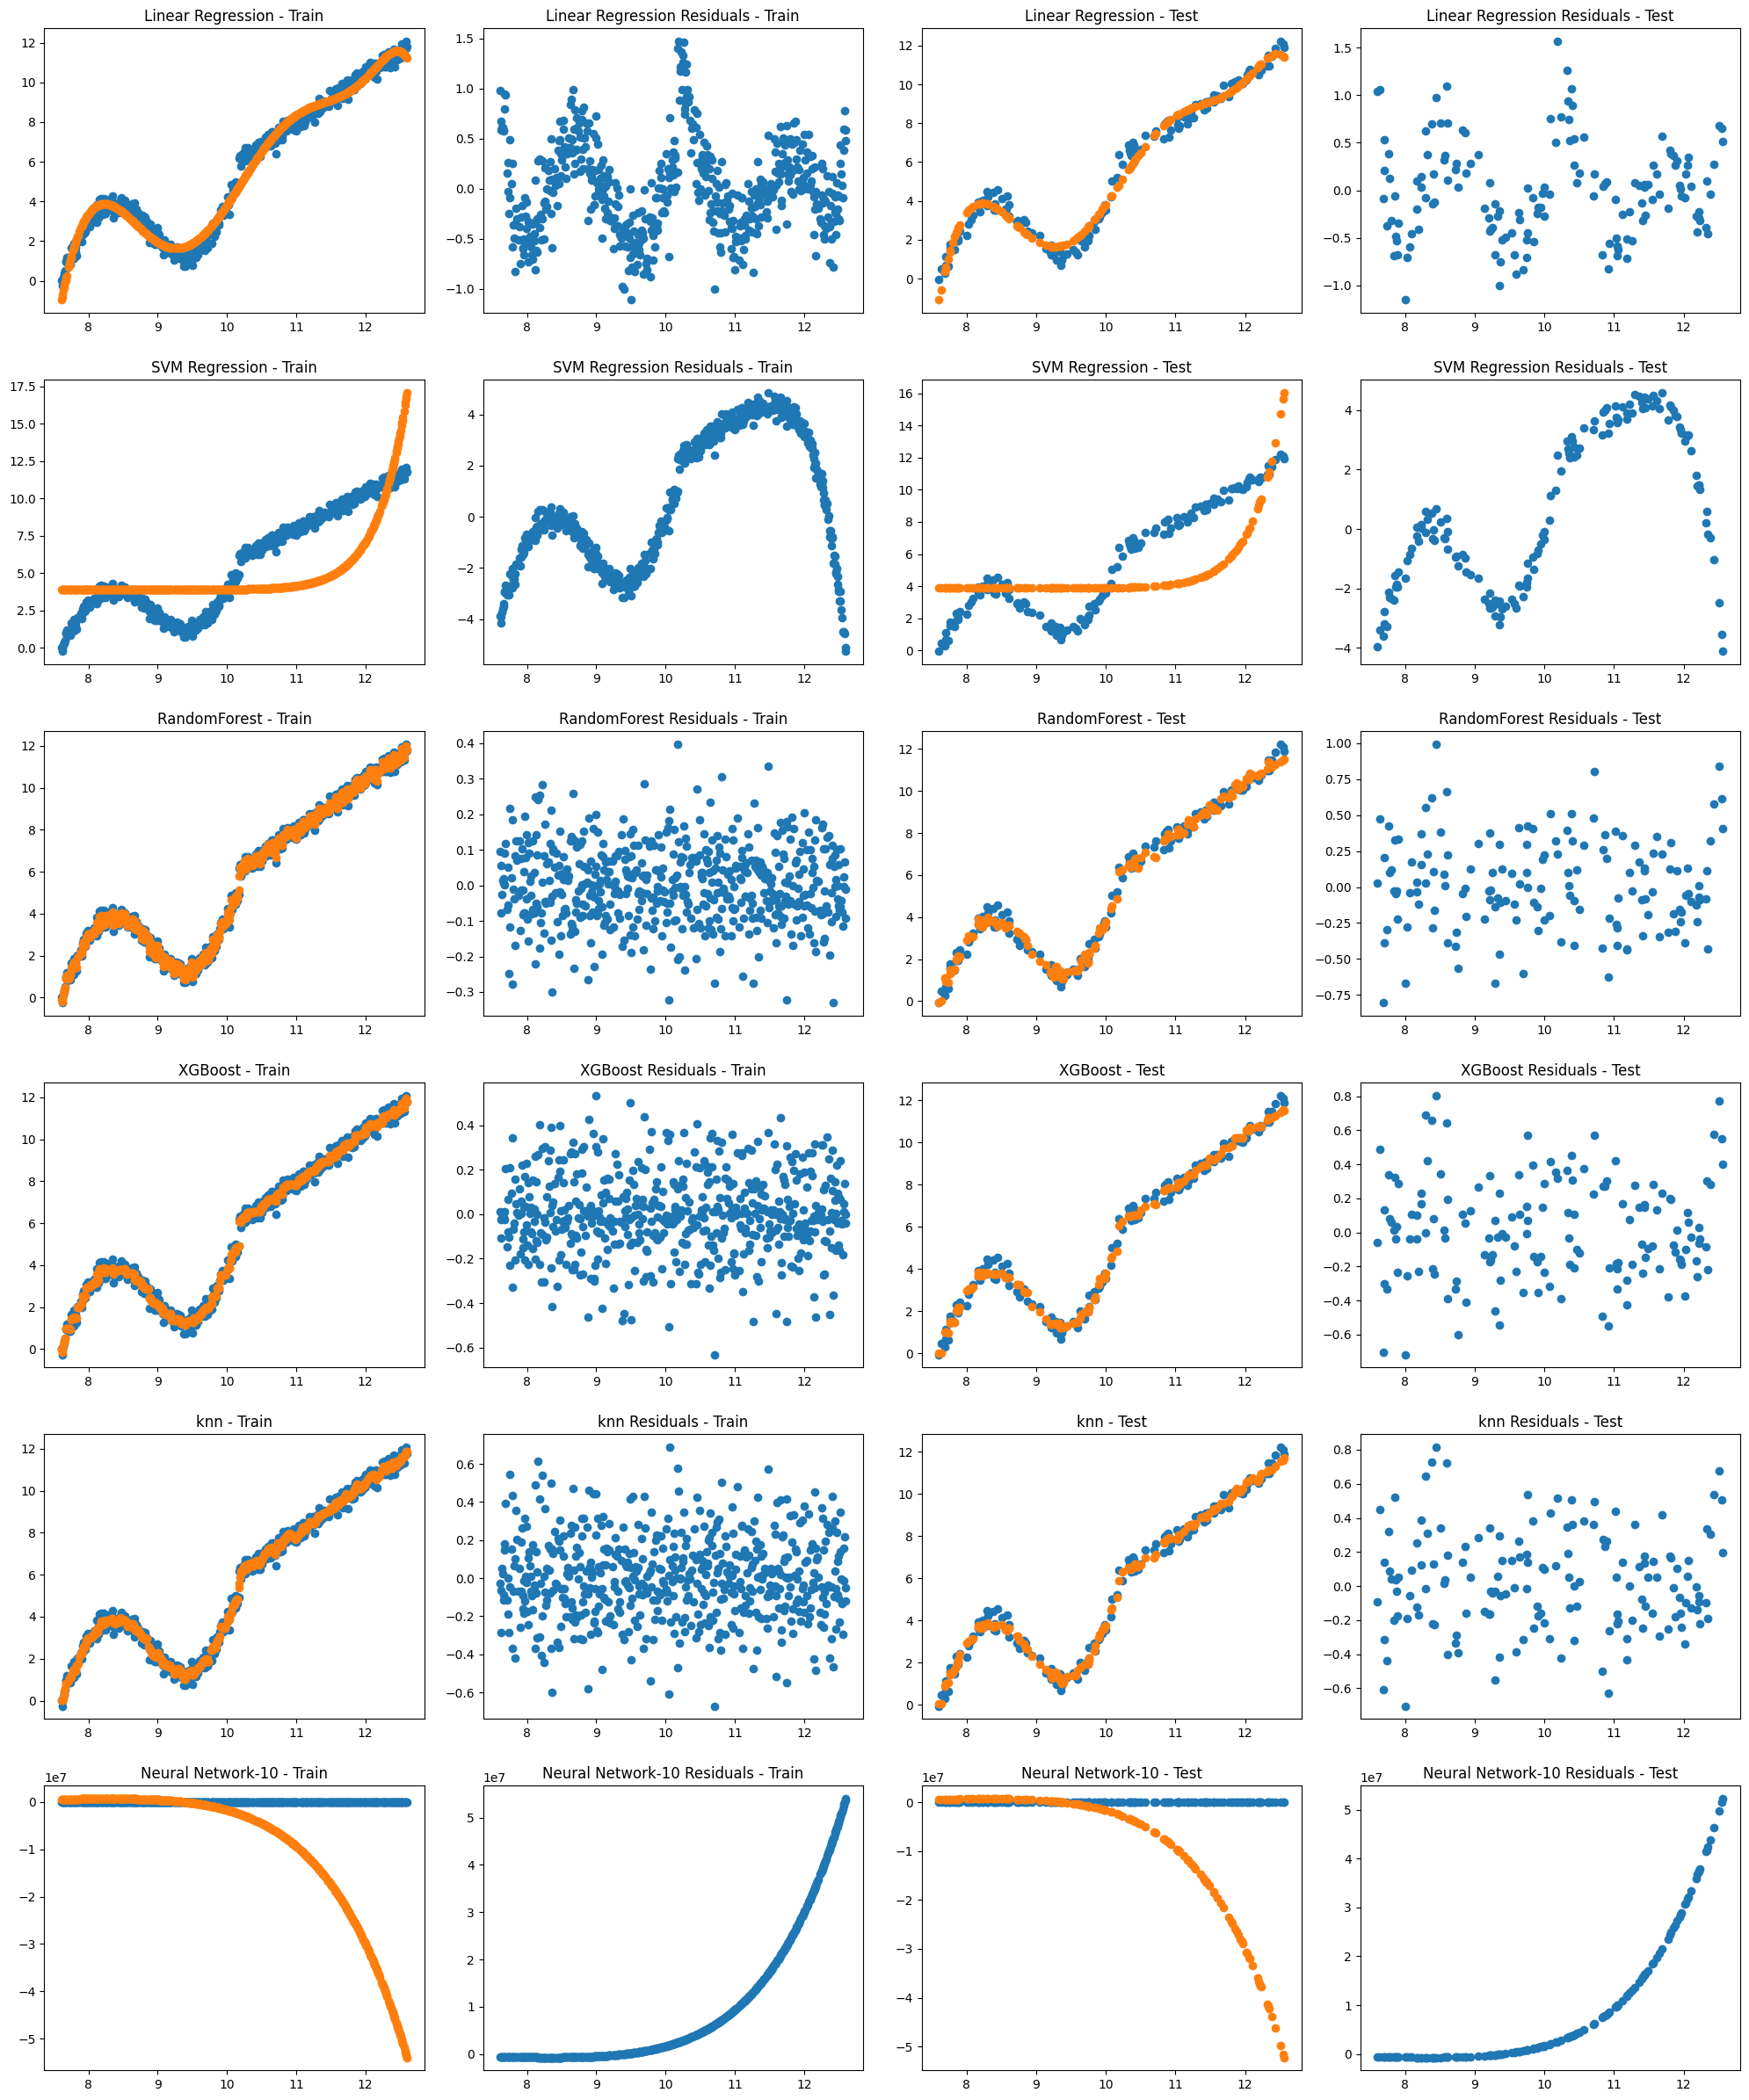

In [34]:
#without standardization of the data for degree 10

# To ensure reproducibility
np.random.seed(42)

# Read data from Excel file
file_path = 'E3.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')


# Separate features and target variable in train data
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

# Separate features and target variable in test data
X_test = test_data.drop(columns=['y'])
y_test = test_data['y']




poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_train_poly, columns=feature_names)
augmented_data['y'] = train_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_train_data.csv', index=False)
####################################
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_test_poly, columns=feature_names)
augmented_data['y'] = test_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_test_data.csv', index=False)
####################################


# Algorithms
algorithms = {
    'Linear Regression': LinearRegression(),
    'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
    'RandomForest': RandomForestRegressor(),
    'XGBoost': GradientBoostingRegressor(),
    'knn': KNeighborsRegressor(),
    'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
}

# Metric tables
metric_table_train = pd.DataFrame()
metric_table_test = pd.DataFrame()


# Create a grid of subplots
fig, axs = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row = -1

# Run the algorithms ... create metrics and plots
for algorithm_name, algorithm in algorithms.items():

    # Train model
    algorithm.fit(X_train_poly, y_train)

    # Train predictions
    y_train_pred = algorithm.predict(X_train_poly)

    # Test predictions
    y_test_pred = algorithm.predict(X_test_poly)

    # Train metrics
    r2_train = algorithm.score(X_train_poly, y_train)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)

    # Test metrics
    r2_test = algorithm.score(X_test_poly, y_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Additional metrics using statsmodels for all algorithms
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
    jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

    durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
    jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)

    # Update metric tables
    metric_table_train.at[algorithm_name, 'R-squared'] = r2_train
    metric_table_train.at[algorithm_name, 'RMSE'] = rmse_train
    metric_table_train.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_train
    metric_table_train.at[algorithm_name, 'Jarque-Bera'] = jb_stat_train
    metric_table_train.at[algorithm_name, 'JB P-value'] = jb_p_value_train

    metric_table_test.at[algorithm_name, 'R-squared'] = r2_test
    metric_table_test.at[algorithm_name, 'RMSE'] = rmse_test
    metric_table_test.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_test
    metric_table_test.at[algorithm_name, 'Jarque-Bera'] = jb_stat_test
    metric_table_test.at[algorithm_name, 'JB P-value'] = jb_p_value_test

    # Create the plots
    fig_row = fig_row+1

    axs[fig_row, 0].scatter(X_train, y_train)
    axs[fig_row, 0].scatter(X_train, y_train_pred)
    axs[fig_row, 0].set_title(algorithm_name + " - Train")

    axs[fig_row, 1].scatter(X_train, residuals_train)
    axs[fig_row, 1].set_title(algorithm_name + " Residuals - Train")

    axs[fig_row, 2].scatter(X_test, y_test)
    axs[fig_row, 2].scatter(X_test, y_test_pred)
    axs[fig_row, 2].set_title(algorithm_name + " - Test")

    axs[fig_row, 3].scatter(X_test, residuals_test)
    axs[fig_row, 3].set_title(algorithm_name + " Residuals - Test")
############################

plt.tight_layout()
plt.show()

In [35]:
# Display the metrics' Tables
print("Metrics - Train Data:\n")
print(metric_table_train.to_string())
print("-------------------------------------------------")

print("Metrics - Test Data:\n")
print(metric_table_test.to_string())

Metrics - Train Data:

                      R-squared          RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression  9.827069e-01  4.543007e-01       0.572057    18.489218  9.663120e-05
SVM Regression     3.946295e-01  2.687931e+00       0.016682    43.824250  3.045685e-10
RandomForest       9.989994e-01  1.092800e-01       2.930430     3.250107  1.969011e-01
XGBoost            9.971463e-01  1.845492e-01       2.372918     1.046859  5.924852e-01
knn                9.958949e-01  2.213447e-01       2.505231     0.733304  6.930509e-01
Neural Network-10 -2.457190e+13  1.712485e+07       0.000101   245.456189  5.010323e-54
-------------------------------------------------
Metrics - Test Data:

                      R-squared          RMSE  Durbin-Watson  Jarque-Bera    JB P-value
Linear Regression  9.801501e-01  4.960630e-01       0.707796     4.669792  9.682056e-02
SVM Regression     4.252236e-01  2.669357e+00       0.030947    13.031702  1.479796e-03
RandomForest       9.9176

c:\Users\ajayt\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but PolynomialFeatures was fitted without feature names
  warnings.warn(


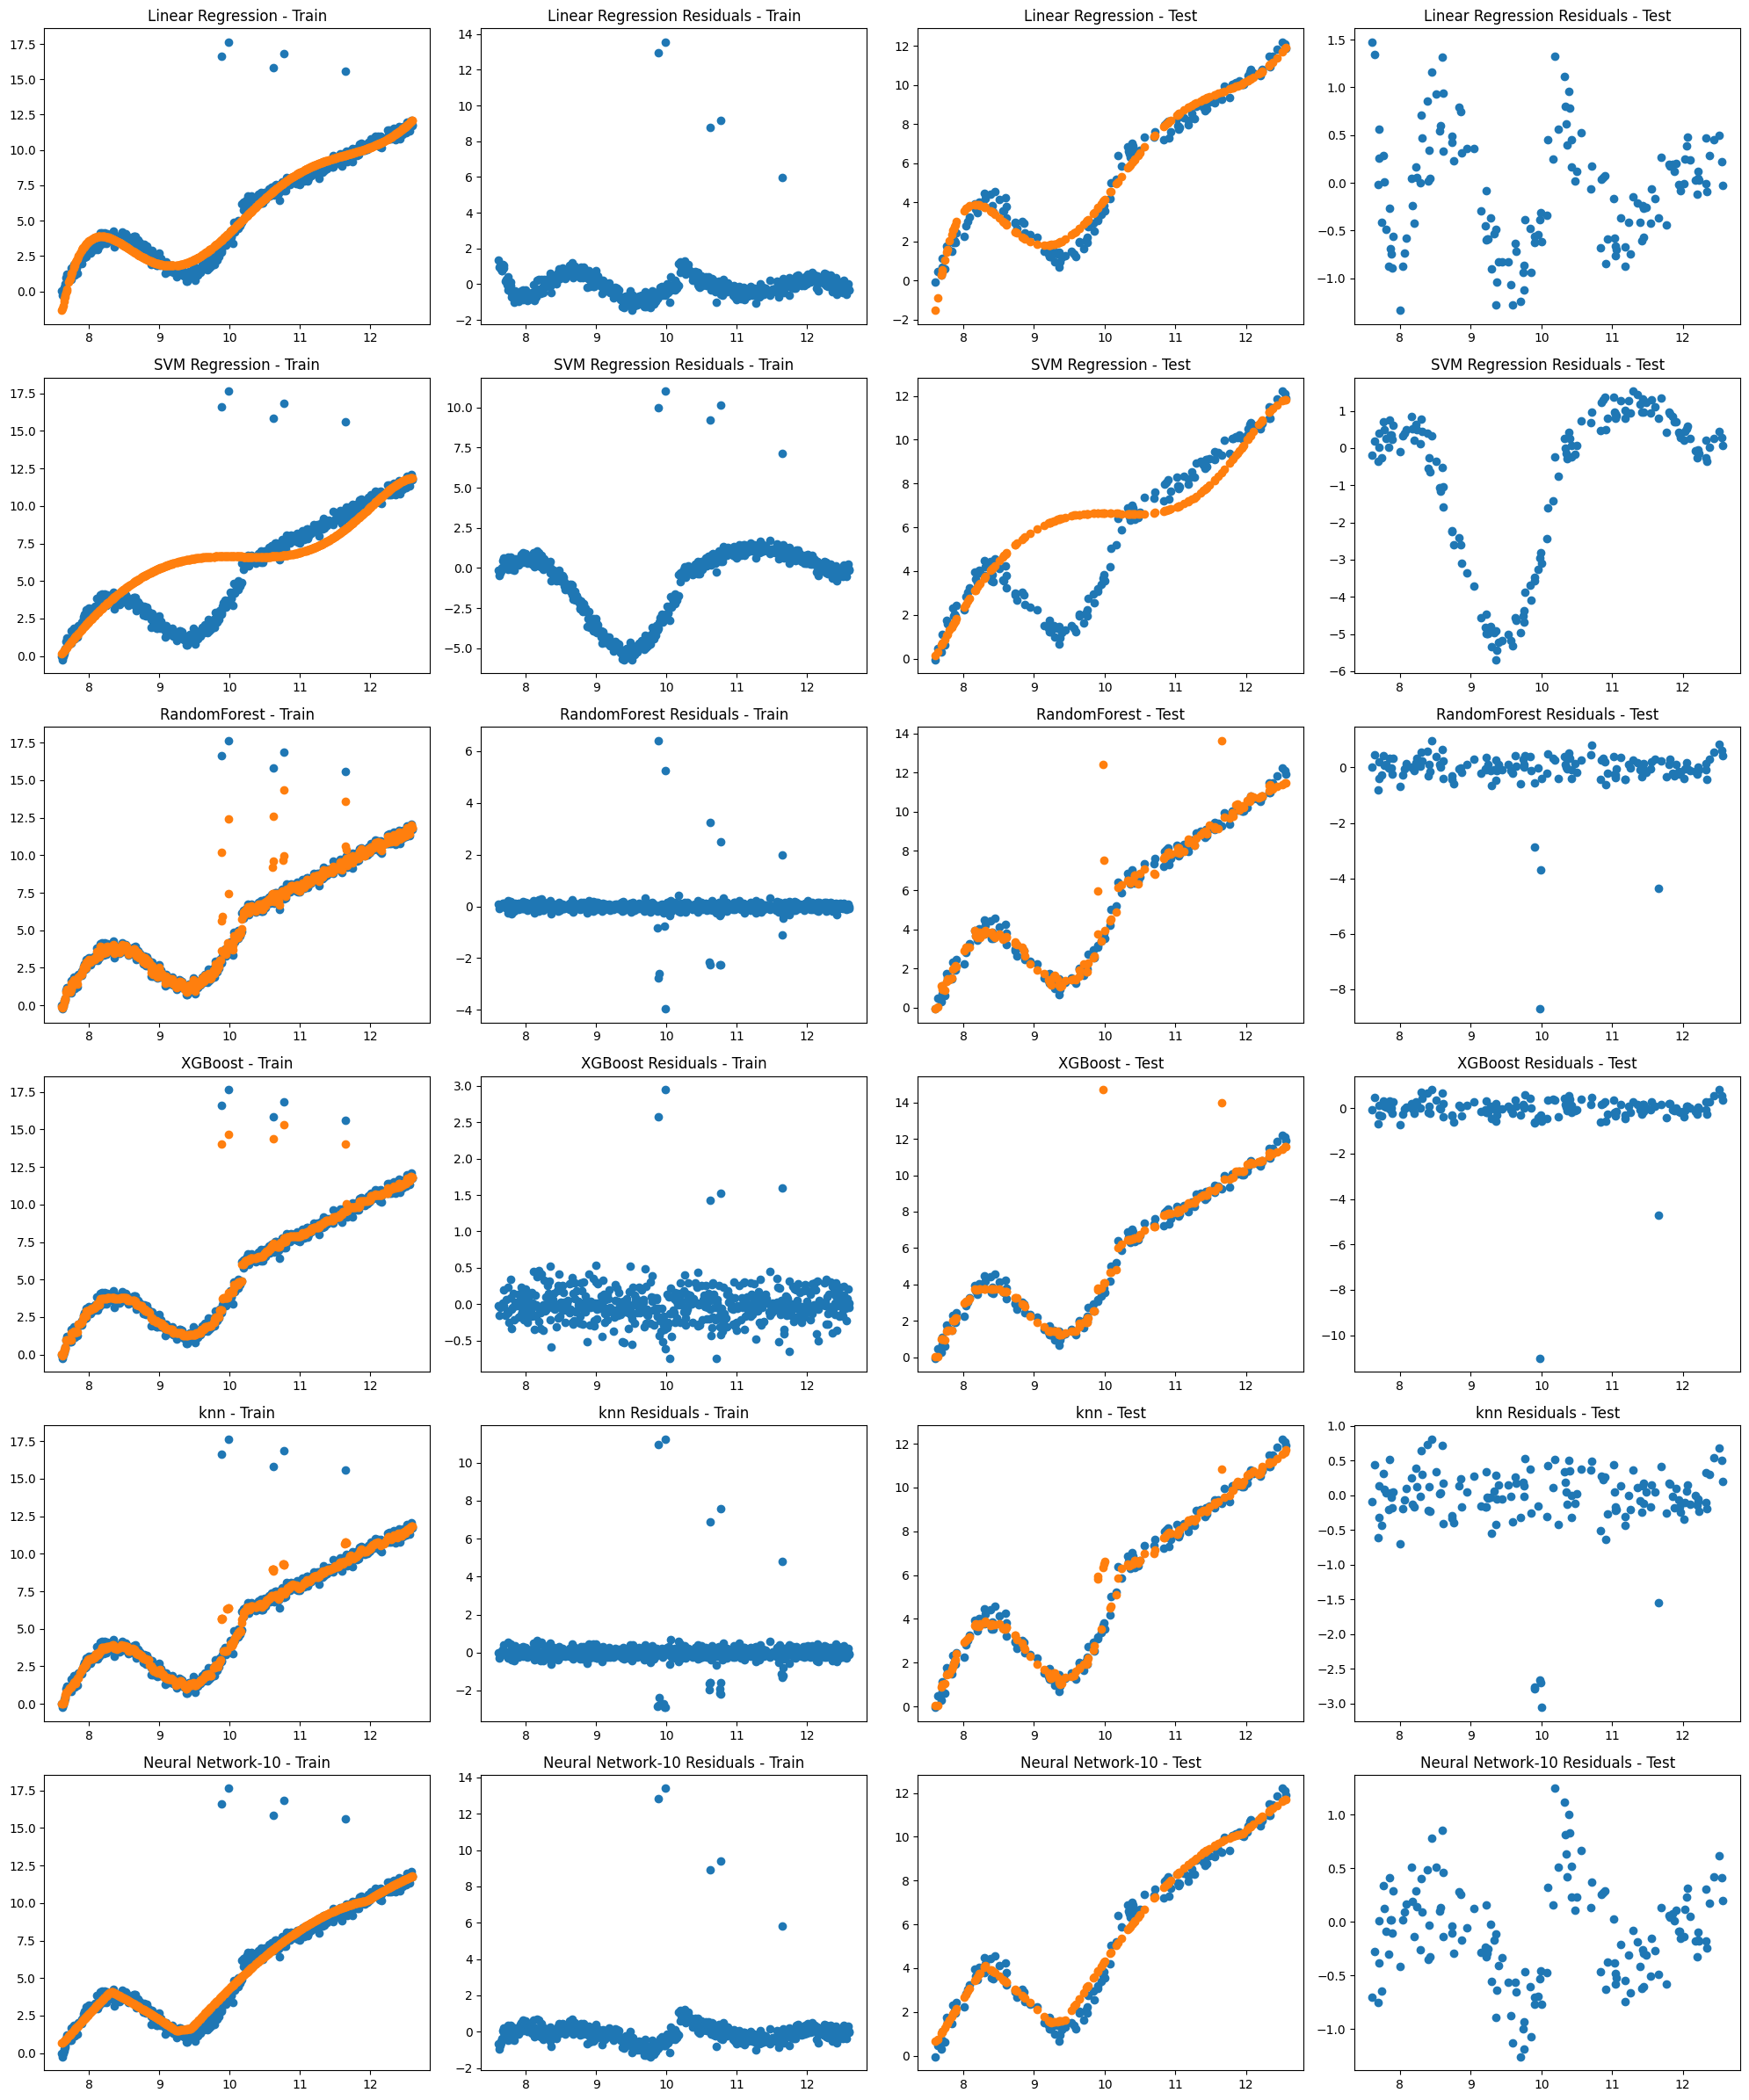

In [36]:
#with outliers for degree 6

# To ensure reproducibility
np.random.seed(42)

# Read data from Excel file
file_path = 'E3.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')

# Separate features and target variable in train data
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

# Separate features and target variable in test data
X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

# # Adding outliers (UNCOMMENT ONLY WHEN REQUIRED! SEE THE PROBLEM STATEMENTs ...)
X_train = np.array(list(X_train['x1']) + [X_train['x1'].mean() + x for x in np.random.randn(5)]).reshape(-1,1)
y_train = np.array(list(y_train) + [y_train.max() + 4 + x for x in np.random.randn(5)])


poly = PolynomialFeatures(degree=6)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)



# standardization of the data
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_train_poly, columns=feature_names)
augmented_data['y'] = train_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_train_data.csv', index=False)
####################################
####################################
# Save the augmented data set to a file for review

# Create dataframe with test data and additional features
# Get feature names
feature_names = poly.get_feature_names_out()
augmented_data = pd.DataFrame(X_test_poly, columns=feature_names)
augmented_data['y'] = test_data['y']

# # Write dataframe to CSV
augmented_data.to_csv('augmented_test_data.csv', index=False)
####################################


# Algorithms
algorithms = {
    'Linear Regression': LinearRegression(),
    'SVM Regression': SVR(kernel='poly'),  # Adjust kernel as needed
    'RandomForest': RandomForestRegressor(),
    'XGBoost': GradientBoostingRegressor(),
    'knn': KNeighborsRegressor(),
    'Neural Network-10': MLPRegressor(hidden_layer_sizes=[10], max_iter=20000),
}

# Metric tables
metric_table_train = pd.DataFrame()
metric_table_test = pd.DataFrame()


# Create a grid of subplots
fig, axs = plt.subplots(len(algorithms), 4, figsize=(20, 4 * len(algorithms)))
fig_row = -1

# Run the algorithms ... create metrics and plots
for algorithm_name, algorithm in algorithms.items():

    # Train model
    algorithm.fit(X_train_poly, y_train)

    # Train predictions
    y_train_pred = algorithm.predict(X_train_poly)

    # Test predictions
    y_test_pred = algorithm.predict(X_test_poly)

    # Train metrics
    r2_train = algorithm.score(X_train_poly, y_train)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)

    # Test metrics
    r2_test = algorithm.score(X_test_poly, y_test)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Additional metrics using statsmodels for all algorithms
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    durbin_watson_stat_train = sm.stats.durbin_watson(residuals_train)
    jb_stat_train, jb_p_value_train, _, _ = sm.stats.jarque_bera(residuals_train)

    durbin_watson_stat_test = sm.stats.durbin_watson(residuals_test)
    jb_stat_test, jb_p_value_test, _, _ = sm.stats.jarque_bera(residuals_test)

    # Update metric tables
    metric_table_train.at[algorithm_name, 'R-squared'] = r2_train
    metric_table_train.at[algorithm_name, 'RMSE'] = rmse_train
    metric_table_train.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_train
    metric_table_train.at[algorithm_name, 'Jarque-Bera'] = jb_stat_train
    metric_table_train.at[algorithm_name, 'JB P-value'] = jb_p_value_train

    metric_table_test.at[algorithm_name, 'R-squared'] = r2_test
    metric_table_test.at[algorithm_name, 'RMSE'] = rmse_test
    metric_table_test.at[algorithm_name, 'Durbin-Watson'] = durbin_watson_stat_test
    metric_table_test.at[algorithm_name, 'Jarque-Bera'] = jb_stat_test
    metric_table_test.at[algorithm_name, 'JB P-value'] = jb_p_value_test

    # Create the plots
    fig_row = fig_row+1

    axs[fig_row, 0].scatter(X_train, y_train)
    axs[fig_row, 0].scatter(X_train, y_train_pred)
    axs[fig_row, 0].set_title(algorithm_name + " - Train")

    axs[fig_row, 1].scatter(X_train, residuals_train)
    axs[fig_row, 1].set_title(algorithm_name + " Residuals - Train")

    axs[fig_row, 2].scatter(X_test, y_test)
    axs[fig_row, 2].scatter(X_test, y_test_pred)
    axs[fig_row, 2].set_title(algorithm_name + " - Test")

    axs[fig_row, 3].scatter(X_test, residuals_test)
    axs[fig_row, 3].set_title(algorithm_name + " Residuals - Test")
############################

plt.tight_layout()
plt.show()


In [37]:
# Display the metrics' Tables for outliers for degree 6
print("Metrics - Train Data:\n")
print(metric_table_train.to_string())
print("-------------------------------------------------")

print("Metrics - Test Data:\n")
print(metric_table_test.to_string())

Metrics - Train Data:

                   R-squared      RMSE  Durbin-Watson    Jarque-Bera    JB P-value
Linear Regression   0.899544  1.137503       0.347445  151552.426493  0.000000e+00
SVM Regression      0.533769  2.450564       0.051834     151.685745  1.153079e-33
RandomForest        0.979081  0.519082       0.774452  125542.541464  0.000000e+00
XGBoost             0.993643  0.286150       1.246634   29119.903663  0.000000e+00
knn                 0.932941  0.929382       0.495940  175594.587772  0.000000e+00
Neural Network-10   0.908161  1.087626       0.369110  210810.169918  0.000000e+00
-------------------------------------------------
Metrics - Test Data:

                   R-squared      RMSE  Durbin-Watson   Jarque-Bera     JB P-value
Linear Regression   0.970786  0.601799       0.491065      2.523623   2.831407e-01
SVM Regression      0.574131  2.297710       0.035652     27.322876   1.166576e-06
RandomForest        0.929675  0.933707       1.474115  17518.681464   0.000

Neural Network (10 Neurons, Degree 1)
Train R²   : 0.9323
Train RMSE: 0.8989
Train DW  : 0.1462
Train JB  : 17.2175 (p = 0.0002)

Test R²   : 0.9215
Test RMSE: 0.9867
Test DW  : 0.1780
Test JB  : 2.7488 (p = 0.2530)


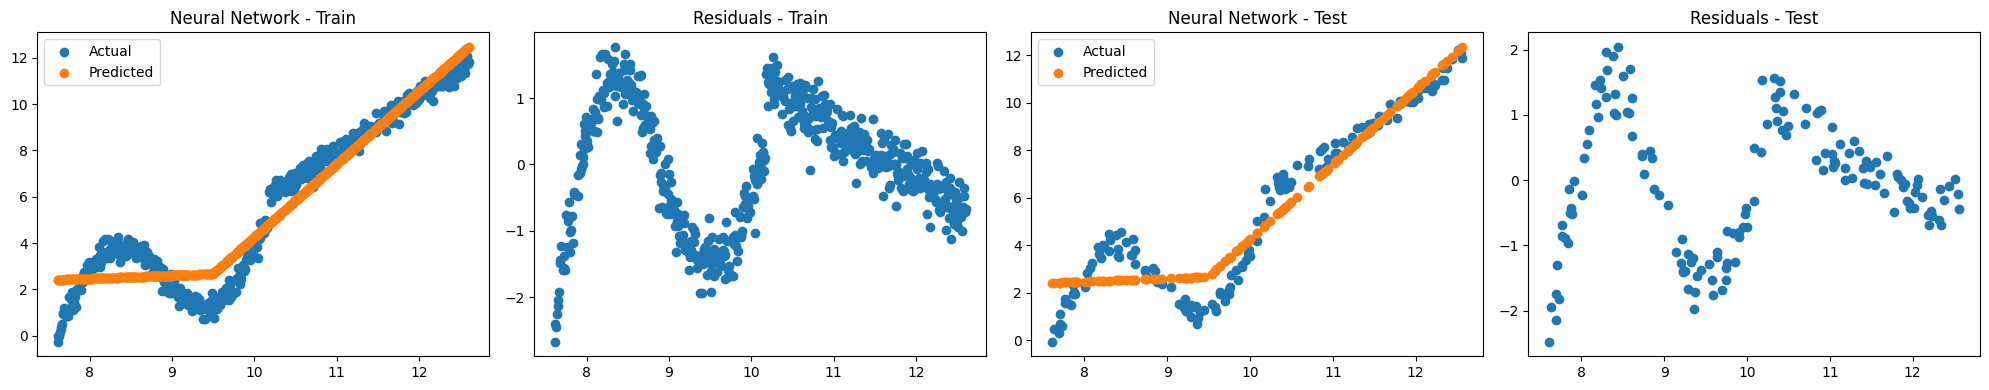

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error

import statsmodels.api as sm

# ==========================================
# Reproducibility
# ==========================================
np.random.seed(42)

# ==========================================
# Read data
# ==========================================
file_path = 'E3.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')

# Separate features and target
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

# ==========================================
# Polynomial Features (Degree 1)
# ==========================================
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# ==========================================
# Standardization
# ==========================================
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

# ==========================================
# Save augmented datasets
# ==========================================
feature_names = poly.get_feature_names_out()

aug_train = pd.DataFrame(X_train_poly, columns=feature_names)
aug_train['y'] = y_train
aug_train.to_csv('augmented_train_data.csv', index=False)

aug_test = pd.DataFrame(X_test_poly, columns=feature_names)
aug_test['y'] = y_test
aug_test.to_csv('augmented_test_data.csv', index=False)

# ==========================================
# Neural Network Model
# ==========================================
nn_model = MLPRegressor(
    hidden_layer_sizes=(10,),
    max_iter=20000,
    random_state=42
)

# Train model
nn_model.fit(X_train_poly, y_train)

# Predictions
y_train_pred = nn_model.predict(X_train_poly)
y_test_pred = nn_model.predict(X_test_poly)

# ==========================================
# Metrics
# ==========================================
# Train metrics
r2_train = nn_model.score(X_train_poly, y_train)
rmse_train = root_mean_squared_error(y_train, y_train_pred)

# Test metrics
r2_test = nn_model.score(X_test_poly, y_test)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

# Residuals
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

# Statistical tests
dw_train = sm.stats.durbin_watson(residuals_train)
jb_train, jb_p_train, _, _ = sm.stats.jarque_bera(residuals_train)

dw_test = sm.stats.durbin_watson(residuals_test)
jb_test, jb_p_test, _, _ = sm.stats.jarque_bera(residuals_test)

# Print metrics
print("Neural Network (10 Neurons, Degree 1)")
print("===================================")
print(f"Train R²   : {r2_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train DW  : {dw_train:.4f}")
print(f"Train JB  : {jb_train:.4f} (p = {jb_p_train:.4f})")
print()
print(f"Test R²   : {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test DW  : {dw_test:.4f}")
print(f"Test JB  : {jb_test:.4f} (p = {jb_p_test:.4f})")

# ==========================================
# Plots
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

# Train fit
axs[0].scatter(X_train, y_train, label='Actual')
axs[0].scatter(X_train, y_train_pred, label='Predicted')
axs[0].set_title("Neural Network - Train")
axs[0].legend()

# Train residuals
axs[1].scatter(X_train, residuals_train)
axs[1].set_title("Residuals - Train")

# Test fit
axs[2].scatter(X_test, y_test, label='Actual')
axs[2].scatter(X_test, y_test_pred, label='Predicted')
axs[2].set_title("Neural Network - Test")
axs[2].legend()

# Test residuals
axs[3].scatter(X_test, residuals_test)
axs[3].set_title("Residuals - Test")

plt.tight_layout()
plt.show()


Neural Network (10 Neurons, Degree 1)
Train R²   : 0.9930
Train RMSE: 0.2899
Train DW  : 1.3953
Train JB  : 10.0347 (p = 0.0066)

Test R²   : 0.9918
Test RMSE: 0.3192
Test DW  : 1.6024
Test JB  : 1.6456 (p = 0.4392)


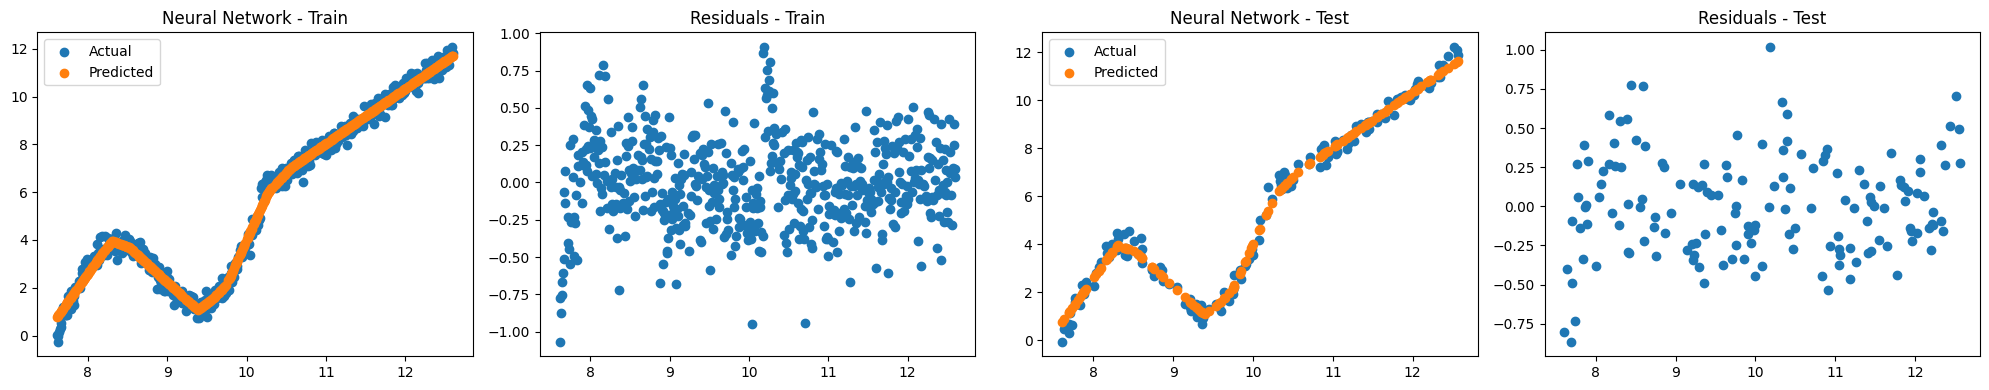

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error

import statsmodels.api as sm

# ==========================================
# Reproducibility
# ==========================================
np.random.seed(42)

# ==========================================
# Read data
# ==========================================
file_path = 'E3.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')

# Separate features and target
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

# ==========================================
# Polynomial Features (Degree 1)
# ==========================================
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# ==========================================
# Standardization
# ==========================================
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

# ==========================================
# Save augmented datasets
# ==========================================
feature_names = poly.get_feature_names_out()

aug_train = pd.DataFrame(X_train_poly, columns=feature_names)
aug_train['y'] = y_train
aug_train.to_csv('augmented_train_data.csv', index=False)

aug_test = pd.DataFrame(X_test_poly, columns=feature_names)
aug_test['y'] = y_test
aug_test.to_csv('augmented_test_data.csv', index=False)

# ==========================================
# Neural Network Model
# ==========================================
nn_model = MLPRegressor(
    hidden_layer_sizes=(10,10,),  # Two hidden layers with 10 neurons each
    max_iter=20000,
    random_state=42
)

# Train model
nn_model.fit(X_train_poly, y_train)

# Predictions
y_train_pred = nn_model.predict(X_train_poly)
y_test_pred = nn_model.predict(X_test_poly)

# ==========================================
# Metrics
# ==========================================
# Train metrics
r2_train = nn_model.score(X_train_poly, y_train)
rmse_train = root_mean_squared_error(y_train, y_train_pred)

# Test metrics
r2_test = nn_model.score(X_test_poly, y_test)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

# Residuals
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

# Statistical tests
dw_train = sm.stats.durbin_watson(residuals_train)
jb_train, jb_p_train, _, _ = sm.stats.jarque_bera(residuals_train)

dw_test = sm.stats.durbin_watson(residuals_test)
jb_test, jb_p_test, _, _ = sm.stats.jarque_bera(residuals_test)

# Print metrics
print("Neural Network (10 Neurons, Degree 1)")
print("===================================")
print(f"Train R²   : {r2_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train DW  : {dw_train:.4f}")
print(f"Train JB  : {jb_train:.4f} (p = {jb_p_train:.4f})")
print()
print(f"Test R²   : {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test DW  : {dw_test:.4f}")
print(f"Test JB  : {jb_test:.4f} (p = {jb_p_test:.4f})")

# ==========================================
# Plots
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

# Train fit
axs[0].scatter(X_train, y_train, label='Actual')
axs[0].scatter(X_train, y_train_pred, label='Predicted')
axs[0].set_title("Neural Network - Train")
axs[0].legend()

# Train residuals
axs[1].scatter(X_train, residuals_train)
axs[1].set_title("Residuals - Train")

# Test fit
axs[2].scatter(X_test, y_test, label='Actual')
axs[2].scatter(X_test, y_test_pred, label='Predicted')
axs[2].set_title("Neural Network - Test")
axs[2].legend()

# Test residuals
axs[3].scatter(X_test, residuals_test)
axs[3].set_title("Residuals - Test")

plt.tight_layout()
plt.show()


Neural Network (10 Neurons, Degree 1)
Train R²   : 0.9935
Train RMSE: 0.2792
Train DW  : 1.5002
Train JB  : 46.4529 (p = 0.0000)

Test R²   : 0.9916
Test RMSE: 0.3225
Test DW  : 1.6196
Test JB  : 0.9423 (p = 0.6243)


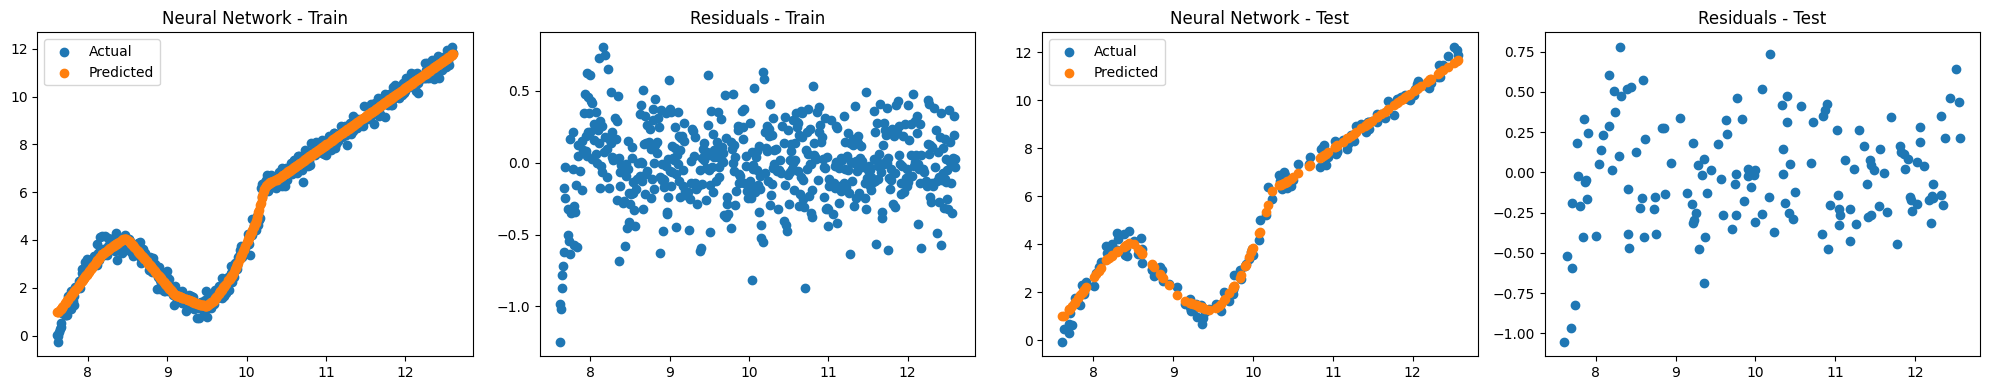

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error

import statsmodels.api as sm

# ==========================================
# Reproducibility
# ==========================================
np.random.seed(42)

# ==========================================
# Read data
# ==========================================
file_path = 'E3.xlsx'
train_data = pd.read_excel(file_path, sheet_name='train')
test_data = pd.read_excel(file_path, sheet_name='test')

# Separate features and target
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']

X_test = test_data.drop(columns=['y'])
y_test = test_data['y']

# ==========================================
# Polynomial Features (Degree 1)
# ==========================================
poly = PolynomialFeatures(degree=1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# ==========================================
# Standardization
# ==========================================
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

# ==========================================
# Save augmented datasets
# ==========================================
feature_names = poly.get_feature_names_out()

aug_train = pd.DataFrame(X_train_poly, columns=feature_names)
aug_train['y'] = y_train
aug_train.to_csv('augmented_train_data.csv', index=False)

aug_test = pd.DataFrame(X_test_poly, columns=feature_names)
aug_test['y'] = y_test
aug_test.to_csv('augmented_test_data.csv', index=False)

# ==========================================
# Neural Network Model
# ==========================================
nn_model = MLPRegressor(
    hidden_layer_sizes=(10,10,10,),  # Three hidden layers with 10 neurons each
    max_iter=20000,
    random_state=42
)

# Train model
nn_model.fit(X_train_poly, y_train)

# Predictions
y_train_pred = nn_model.predict(X_train_poly)
y_test_pred = nn_model.predict(X_test_poly)

# ==========================================
# Metrics
# ==========================================
# Train metrics
r2_train = nn_model.score(X_train_poly, y_train)
rmse_train = root_mean_squared_error(y_train, y_train_pred)

# Test metrics
r2_test = nn_model.score(X_test_poly, y_test)
rmse_test = root_mean_squared_error(y_test, y_test_pred)

# Residuals
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

# Statistical tests
dw_train = sm.stats.durbin_watson(residuals_train)
jb_train, jb_p_train, _, _ = sm.stats.jarque_bera(residuals_train)

dw_test = sm.stats.durbin_watson(residuals_test)
jb_test, jb_p_test, _, _ = sm.stats.jarque_bera(residuals_test)

# Print metrics
print("Neural Network (10 Neurons, Degree 1)")
print("===================================")
print(f"Train R²   : {r2_train:.4f}")
print(f"Train RMSE: {rmse_train:.4f}")
print(f"Train DW  : {dw_train:.4f}")
print(f"Train JB  : {jb_train:.4f} (p = {jb_p_train:.4f})")
print()
print(f"Test R²   : {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test DW  : {dw_test:.4f}")
print(f"Test JB  : {jb_test:.4f} (p = {jb_p_test:.4f})")

# ==========================================
# Plots
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

# Train fit
axs[0].scatter(X_train, y_train, label='Actual')
axs[0].scatter(X_train, y_train_pred, label='Predicted')
axs[0].set_title("Neural Network - Train")
axs[0].legend()

# Train residuals
axs[1].scatter(X_train, residuals_train)
axs[1].set_title("Residuals - Train")

# Test fit
axs[2].scatter(X_test, y_test, label='Actual')
axs[2].scatter(X_test, y_test_pred, label='Predicted')
axs[2].set_title("Neural Network - Test")
axs[2].legend()

# Test residuals
axs[3].scatter(X_test, residuals_test)
axs[3].set_title("Residuals - Test")

plt.tight_layout()
plt.show()
